In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
nltk.download('punkt')

import re


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Iva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
import pandas as pd

df = pd.read_csv('../data/IMDB Dataset.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df['sentiment'].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
review       str
sentiment    str
dtype: object
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
print(df['review'][1])

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.


In [5]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print(f"Prosečan broj reči: {df['word_count'].mean():.0f}")
print(f"Najduža recenzija: {df['word_count'].max()} reči")
print(f"Najkraća recenzija: {df['word_count'].min()} reči")

Prosečan broj reči: 231
Najduža recenzija: 2470 reči
Najkraća recenzija: 4 reči


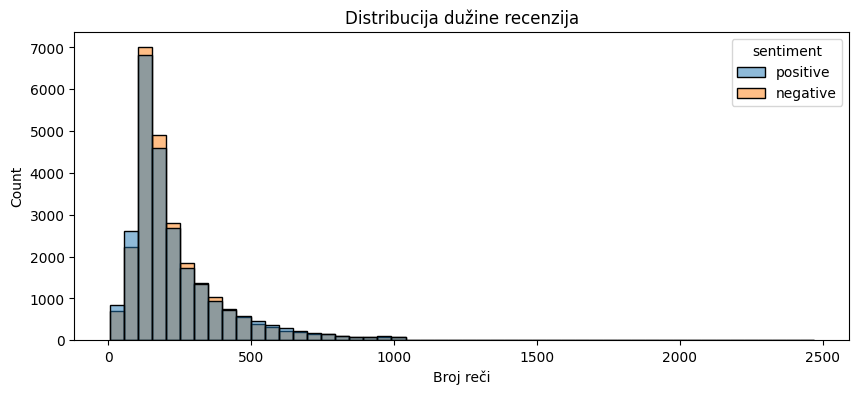

In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50)
plt.title('Distribucija dužine recenzija')
plt.xlabel('Broj reči')
plt.show()

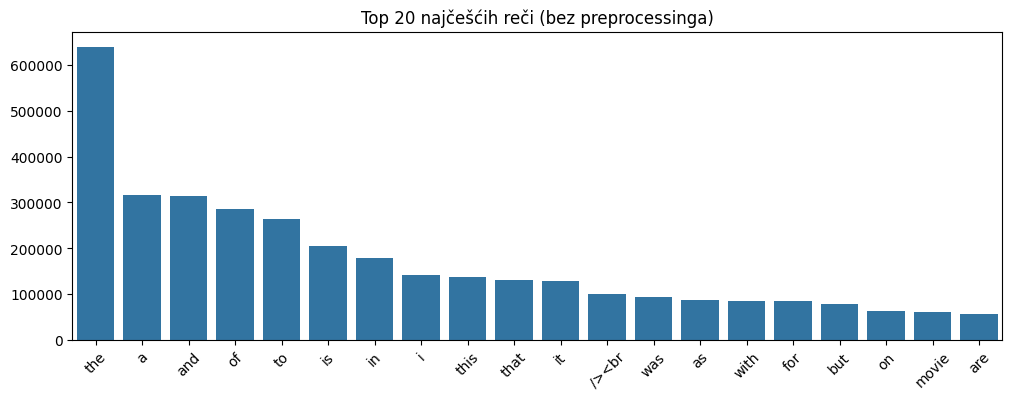

In [7]:
all_words = ' '.join(df['review']).lower().split()
most_common = Counter(all_words).most_common(20)

words, counts = zip(*most_common)
plt.figure(figsize=(12, 4))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 20 najčešćih reči (bez preprocessinga)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['has_html'] = df['review'].apply(lambda x: bool(re.search(r'<.*?>', x)))
print(f"Recenzija sa HTML tagovima: {df['has_html'].sum()}")

Recenzija sa HTML tagovima: 29202


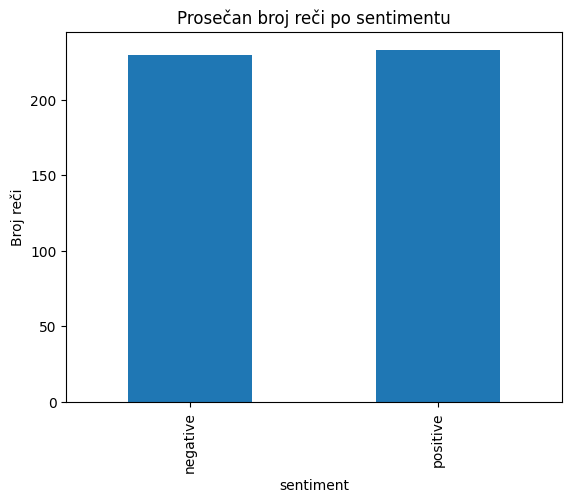

In [12]:
df.groupby('sentiment')['word_count'].mean().plot(kind='bar')
plt.title('Prosečan broj reči po sentimentu')
plt.ylabel('Broj reči')
plt.show()